# Example: for GHZ state:

We prepare a GHZ state on ``nqubits`` and execute it with the optimal layout vs a naive layout taken by default.

Note that the framework of ``iqm-qubit-selector`` currently supports ``qiskit`` circuits.


In [ ]:
import os
from iqm.qubit_selector.qubit_selector import *
from iqm.qubit_selector.qiskit_utils import get_circuit, CircuitType, perform_backend_transpilation
from iqm.qiskit_iqm import IQMProvider
from qiskit.visualization import plot_histogram

In [ ]:
# Input your Resonance token
token = "XXXXXXXX"  # Replace with your actual token
os.environ["IQM_TOKEN"] = token

iqm_server_url = "https://<your-iqm-server-url>"  # Replace with your IQM server URL
quantum_computer = "qc_name"  # Replace with your quantum computer name if needed
provider = IQMProvider(iqm_server_url, quantum_computer = quantum_computer)
backend = provider.get_backend()

### Define the GHZ state and find the optimal layout.

In [23]:
nqubits = 6
# Possible choices for pre-defined circuits 'ghz', 'qft', 'random', 'wstate', 'quantum_volume' 'qaoa'
qc_algo = get_circuit(CircuitType.GHZ, nqubits) ## plug in your qiskit quantum circuit of interest

layouts, cost = CostEvaluator(backend=backend, quantum_circuit=qc_algo).get_top_layouts(num_layouts=50)
print("Top 10 qiskit layouts and their costs:")
for layout, c in zip(layouts[:10], cost[:10]):
    print(f"Layout: {layout}, Cost: {c*100:.2f}%")

[04-18 19:16:44;I] Number of layouts to evaluate: 412
[04-18 19:16:48;I] Cost evaluation has begun using cost function "gate_cost_cz".
Top 10 qiskit layouts and their costs:
Layout: [13, 15, 16, 17, 18, 19], Cost: 2.09%
Layout: [11, 13, 14, 15, 16, 17], Cost: 2.11%
Layout: [8, 13, 15, 17, 18, 19], Cost: 2.12%
Layout: [12, 13, 15, 17, 18, 19], Cost: 2.12%
Layout: [10, 13, 15, 17, 18, 19], Cost: 2.14%
Layout: [13, 14, 15, 16, 17, 18], Cost: 2.19%
Layout: [13, 14, 15, 17, 18, 19], Cost: 2.23%
Layout: [9, 14, 15, 17, 18, 19], Cost: 2.24%
Layout: [10, 13, 14, 15, 17, 18], Cost: 2.24%
Layout: [4, 9, 11, 14, 15, 16], Cost: 2.27%


### Execute on a naively chosen layout on the hardware:

[04-18 19:16:49;I] Waiting for job 019da198-612d-7700-9b5b-1e3f4a6eadc1 to finish...


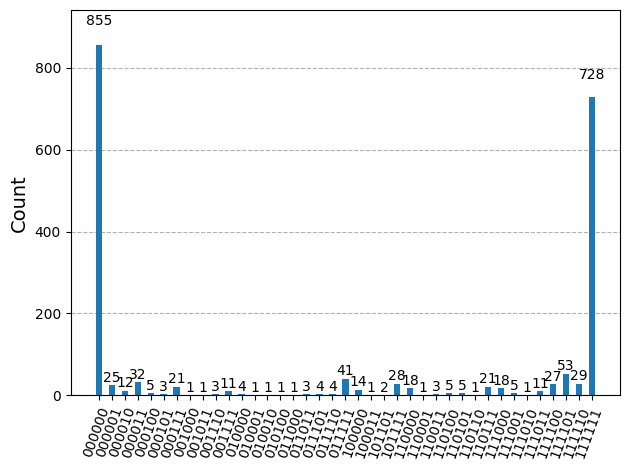

In [24]:
qc_t = transpile(qc_algo, backend=backend, optimization_level=3)
num_shots = 2000
job = backend.run(qc_t, shots=num_shots).result()
counts_naive = job.get_counts()
plot_histogram(counts_naive)

### Execute on an optimal layout found by qubit_selector:

As you see from ``counts_qubit_selector``, the GHZ state is better prepared by choosing the optimal layout from qubit-selector.

Best layout qubit names: ['QB14', 'QB16', 'QB17', 'QB18', 'QB19', 'QB20']
[04-18 19:16:54;I] Waiting for job 019da198-752b-78c0-a6e3-a666f06d22fc to finish...


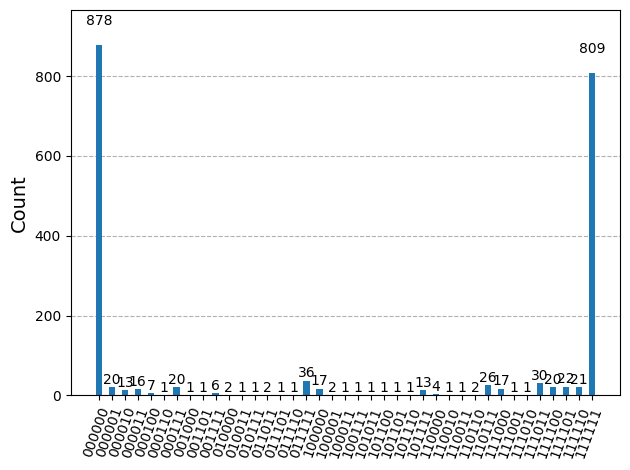

In [25]:
best_layout = layouts[0]
best_layout_qubit_names = [backend.index_to_qubit_name(q) for q in best_layout] ## qubit names corresponding to the best layout

print(f"Best layout qubit names: {best_layout_qubit_names}")

qc_t = perform_backend_transpilation( ## transpile the circuit to the best layout and coupling map
                    [qc_algo],
                    backend,
                    best_layout,
                    backend.coupling_map.reduce(mapping=best_layout),
                    qiskit_optim_level=3,
)

job = backend.run(qc_t, shots=num_shots).result()
counts_qubit_selector = job.get_counts()
plot_histogram(counts_qubit_selector)

### Evaluate the Hellinger fidelity:

The performance of qubit-selector is highlighted by achieving a higher GHZ fidelity compared to the naive run.

In [26]:
from qiskit.quantum_info import hellinger_fidelity

counts_ideal = {'0'*nqubits: num_shots//2, '1'*nqubits: num_shots//2}
fidelity_naive = hellinger_fidelity(counts_ideal, counts_naive)
fidelity_qubit_selector = hellinger_fidelity(counts_ideal, counts_qubit_selector)

print(f"GHZ Hellinger Fidelity naive: {fidelity_naive:.4f}")
print(f"GHZ Hellinger Fidelity qubit selector: {fidelity_qubit_selector:.4f}")

GHZ Hellinger Fidelity naive: 0.7902
GHZ Hellinger Fidelity qubit selector: 0.8431
